# **Loan Default Prediction**

# Problem Statment:

Description: Banks earn a major revenue from lending loans. But it is often associated with risk. The borrower's may default on the loan. To mitigate this issue, the banks have decided to use Machine Learning to overcome this issue. They have collected past data on the loan borrowers & would like you to develop a strong ML Model to classify if any new borrower is likely to default or not.

The dataset is enormous & consists of multiple deteministic factors like borrowe's income, gender, loan pupose etc. The dataset is subject to strong multicollinearity & empty values. Can you overcome these factors & build a strong classifier to predict defaulters?

Objective: Understand the Dataset & cleanup (if required). Build classification model to predict weather the loan borrower will default or not. Also fine-tune the hyperparameters & compare the evaluation metrics of vaious classification algorithms.

image.png

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/loan-default-dataset/Loan_Default.csv


# Features

In [ ]:
ID = "Customer Identity of Applicant"
year = "Year of Application"
loan_limit = "maximum available amount of the loan allowed to be taken"
Gender = "sex type"
approv_in_adv = "Is loan pre-approved or not"
loan_type = "Type of loan"
loan_purpose = "the reason you want to borrow money"
Credit_Worthiness = "is how a lender determines that you will default on your debt obligations, or how worthy you are to receive new credit."
open_credit = "is a pre-approved loan between a lender and a borrower. It allows the borrower to make repeated withdrawals up to a certain limit."
business_or_commercial = "Usage type of the loan amount"
loan_amount = "The exact loan amount"
rate_of_interest = "is the amount a lender charges a borrower and is a percentage of the principal the amount loaned."
Interest_rate_spread = "the difference between the interest rate a financial institution pays to depositors and the interest rate it receives from loans"
Upfront_charges = "Fee paid to a lender by a borrower as consideration for making a new loan"
term = "the loan's repayment period"
Neg_ammortization = "refers to a situation when a loan borrower makes a payment less than the standard installment set by the bank."
interest_only = "amount of interest only without principles"
lump_sum_payment = "is an amount of money that is paid in one single payment rather than in installments."
property_value = "the present worth of future benefits arising from the ownership of the property"
construction_type = "Collateral construction type"
occupancy_type = "classifications refer to categorizing structures based on their usage"
Secured_by = "Type of Collateral"
total_units = "number of units"
income = "refers to the amount of money, property, and other transfers of value received over a set period of time"
credit_type = "type of credit"
co_applicant_credit_type = "is an additional person involved in the loan application process. Both applicant and co-applicant apply and sign for the loan"
age = "applicant's age"
submission_of_application = "Ensure the application is complete or not"
LTV = "life-time value (LTV) is a prognostication of the net profit"
Region = "applicant's place"
Security_Type = "Type of Collateral"
status = "Loan status (Approved/Declined)"
dtir1 = "debt-to-income ratio"

# Load the data

In [ ]:
df = pd.read_csv("/kaggle/input/loan-default-dataset/Loan_Default.csv")
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


#  looking for More information of our data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [ ]:
df['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [ ]:
df.isna().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

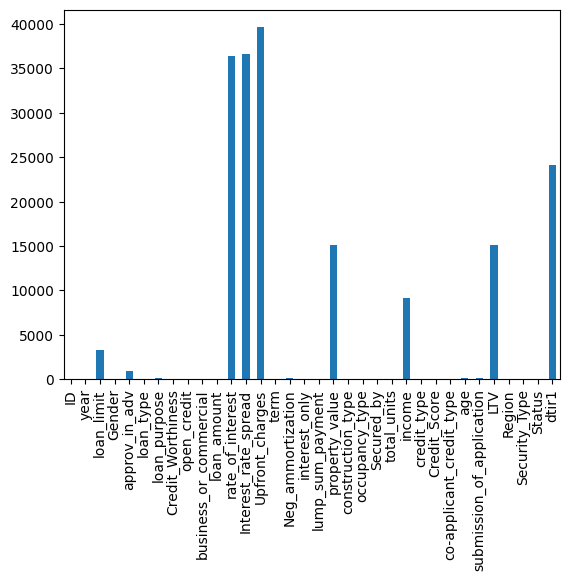

In [ ]:
df.isna().sum().plot.bar()
plt.show()

Removing columns ID and year.

In [ ]:
df = df.drop(["ID","year"], axis = "columns")
df.head()

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [ ]:
df.nunique().sum

<bound method Series.sum of loan_limit                       2
Gender                           4
approv_in_adv                    2
loan_type                        3
loan_purpose                     4
Credit_Worthiness                2
open_credit                      2
business_or_commercial           2
loan_amount                    211
rate_of_interest               131
Interest_rate_spread         22516
Upfront_charges              58271
term                            26
Neg_ammortization                2
interest_only                    2
lump_sum_payment                 2
property_value                 385
construction_type                2
occupancy_type                   3
Secured_by                       2
total_units                      4
income                        1001
credit_type                      4
Credit_Score                   401
co-applicant_credit_type         2
age                              7
submission_of_application        2
LTV                        

# Checking if the Loan defaulter is dependent on Gender

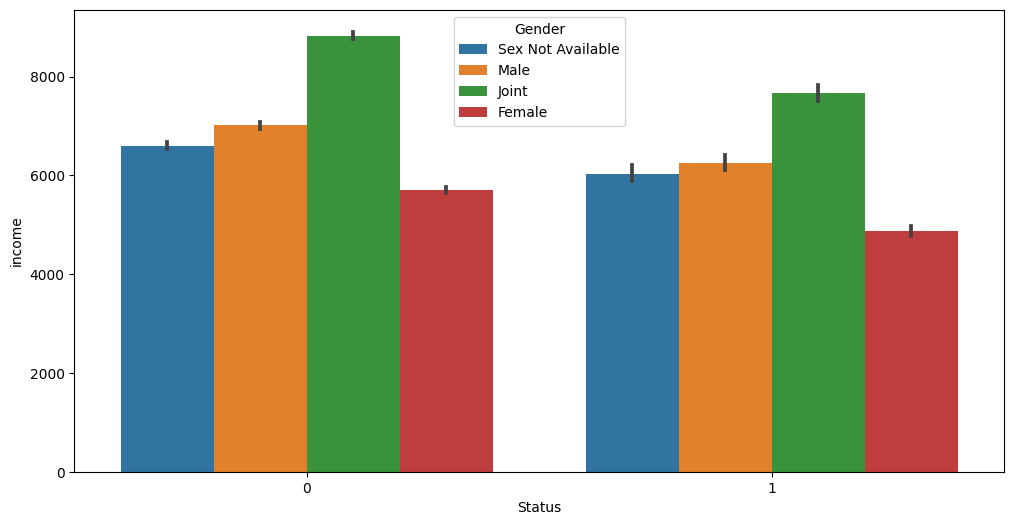

In [ ]:
fig,ax=plt.subplots()
sns.barplot(data=df,x='Status',y='income',hue='Gender')
fig.set_size_inches([12,6])
plt.show()

In [ ]:
df['Gender'].value_counts()

Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

# How Loan defaulter is related to Credit score and Loan Amount


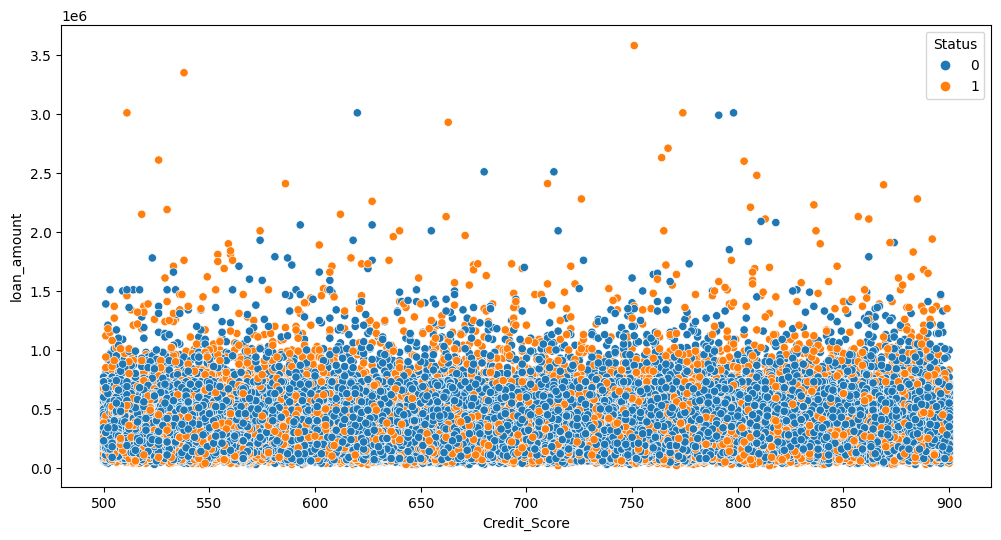

In [ ]:
fig,ax=plt.subplots()
sns.scatterplot(x='Credit_Score',y='loan_amount',data=df,hue='Status')
fig.set_size_inches([12,6])
plt.show()

# Let plot Pie and count plot


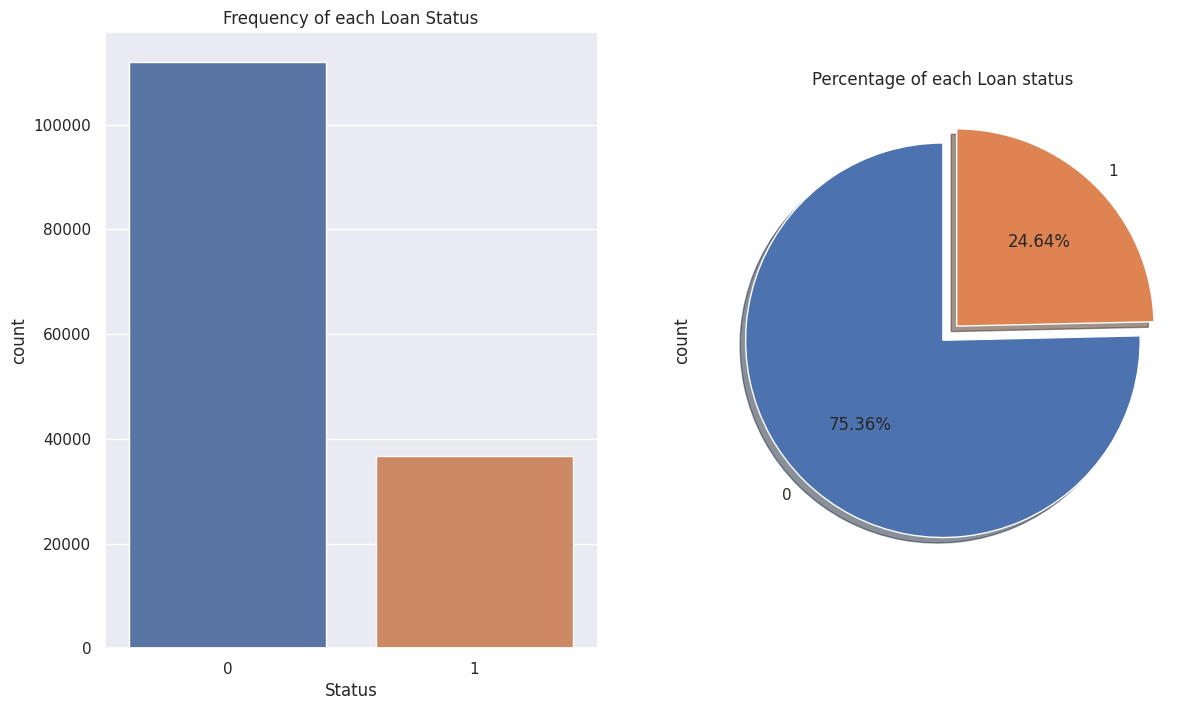

In [ ]:
sns.set_theme()
fig, axs = plt.subplots(1,2,figsize=(14,8))
sns.countplot(x='Status',data=df,ax=axs[0])
axs[0].set_title("Frequency of each Loan Status")
df.Status.value_counts().plot(x=None,y=None, kind='pie', ax=axs[1],shadow =True,explode = (0, 0.1,),autopct='%1.2f%%',startangle=90 )
axs[1].set_title("Percentage of each Loan status")
plt.show()

This clearly is a case of an imbalanced class problem where the value of class is far less than the other. There are cost function based approaches and sampling based approaches for handling this kind of problem which we will use later so that our model doesn't exhibit high bias while trying to predict if a loan will default or not.

A common thing to predict in datasets like these are if a new loan will get default or not. I'll be keeping loans with default status as my target variable.

Here, We have finalize loan status as our target variable which has now 24 % are defaulters for the loan payment.

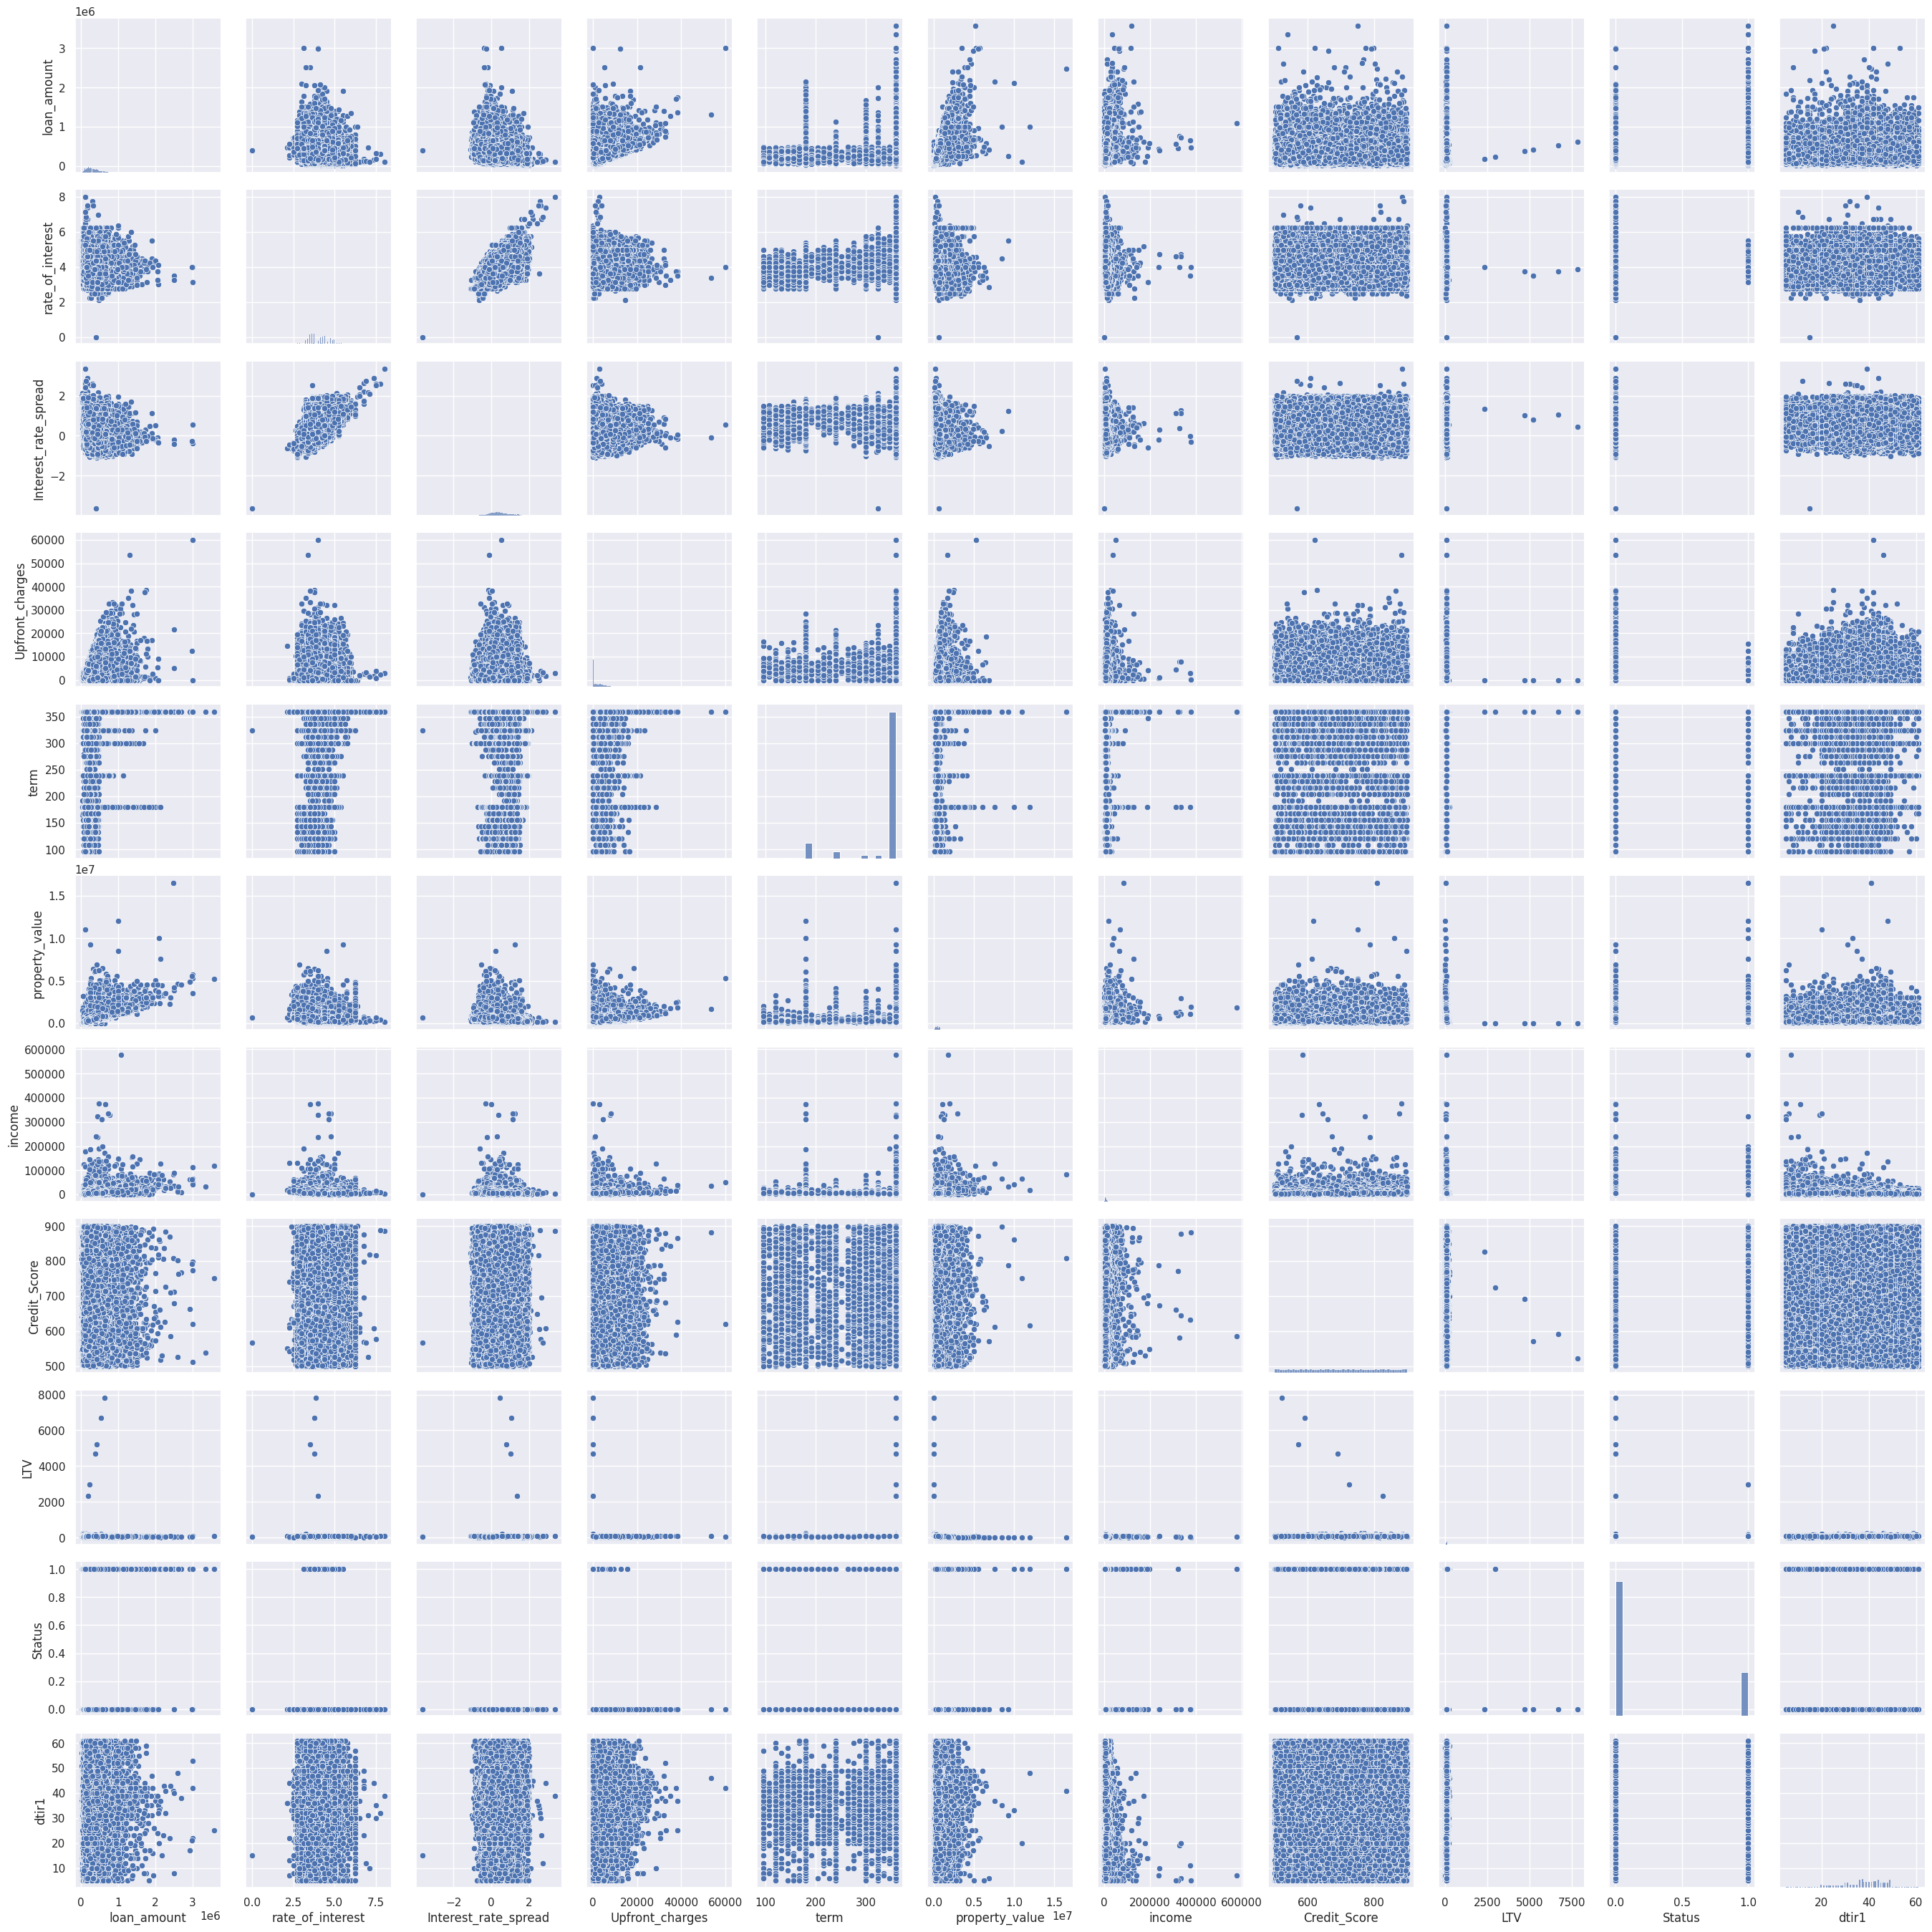

In [ ]:
sns.pairplot(df)

<Axes: xlabel='loan_type', ylabel='count'>

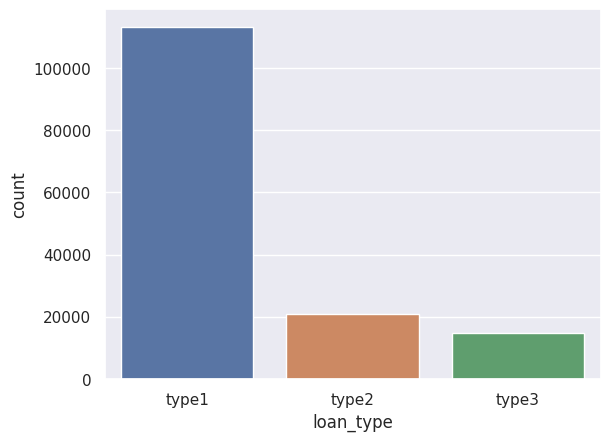

In [ ]:
sns.countplot(data=df , x='loan_type')

<Axes: xlabel='Status', ylabel='count'>

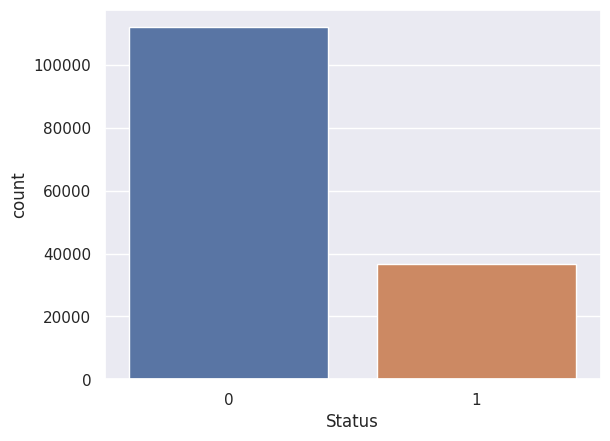

In [ ]:
sns.countplot(data=df , x='Status')

<Axes: xlabel='age', ylabel='count'>

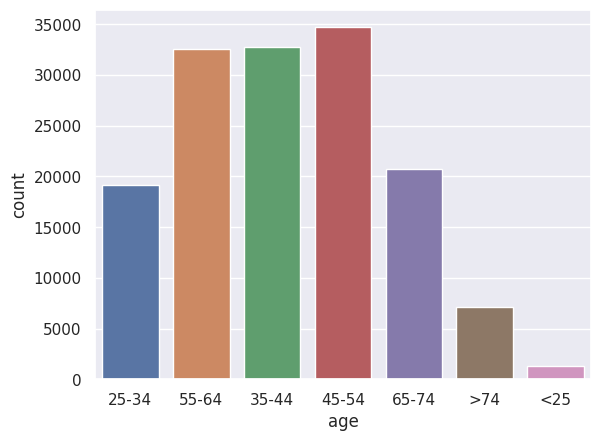

In [ ]:
sns.countplot(data=df , x='age')

<Axes: xlabel='rate_of_interest', ylabel='income'>

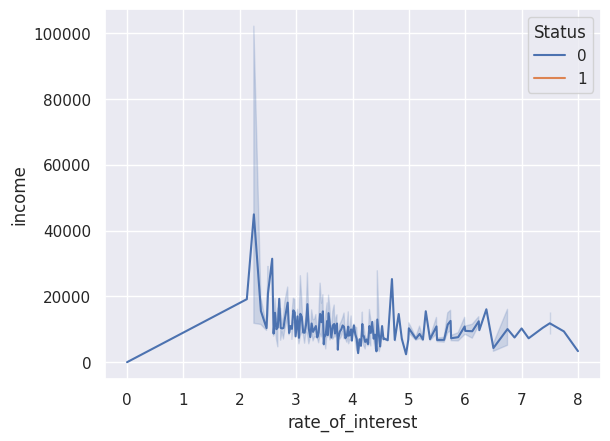

In [ ]:
sns.lineplot(data=df, x="rate_of_interest", y="income", hue="Status")

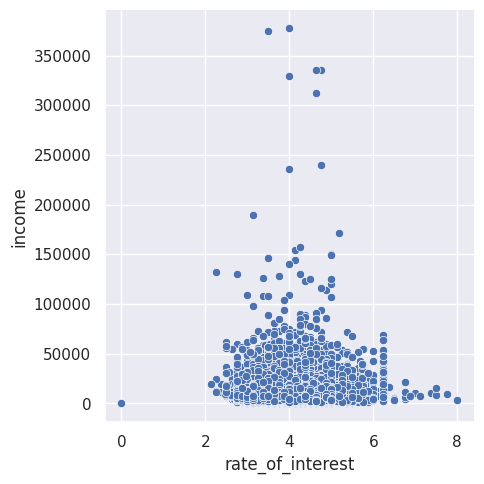

In [ ]:
sns.relplot(x ="rate_of_interest", y ="income",data = df)

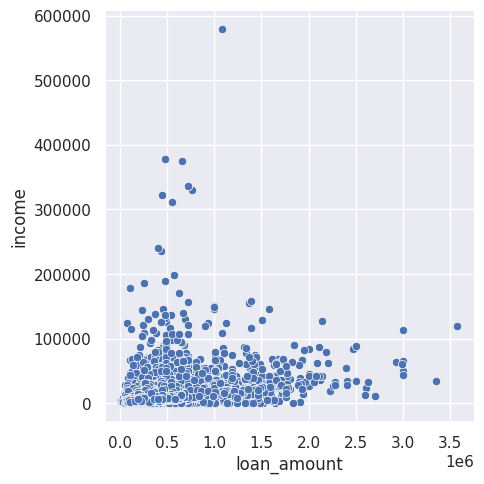

In [ ]:
sns.relplot(x ="loan_amount", y ="income",data = df)

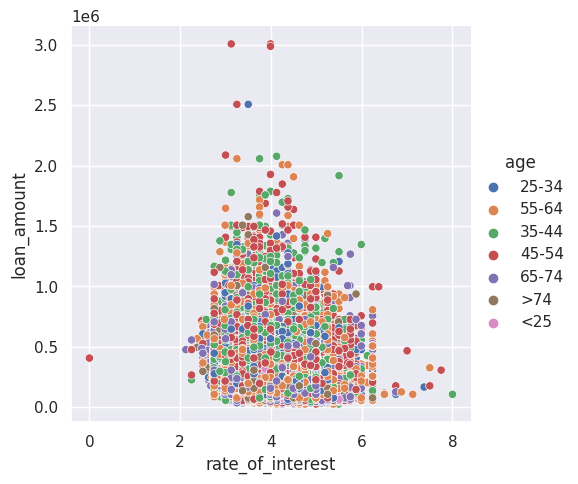

In [ ]:
sns.relplot(x ="rate_of_interest", y ="loan_amount", hue='age' ,data = df)

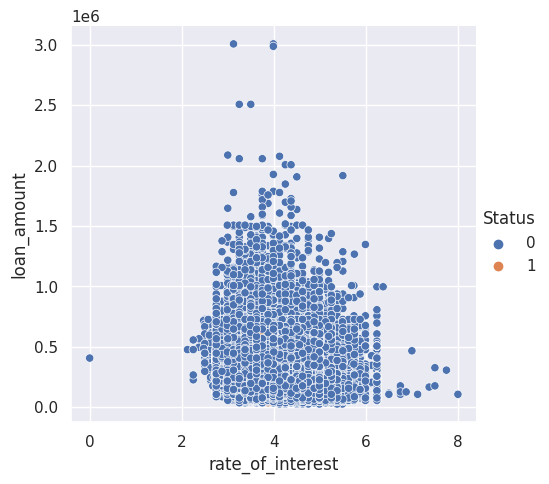

In [ ]:
sns.relplot(x ="rate_of_interest", y ="loan_amount", hue='Status' ,data = df)

<Axes: xlabel='loan_amount', ylabel='Density'>

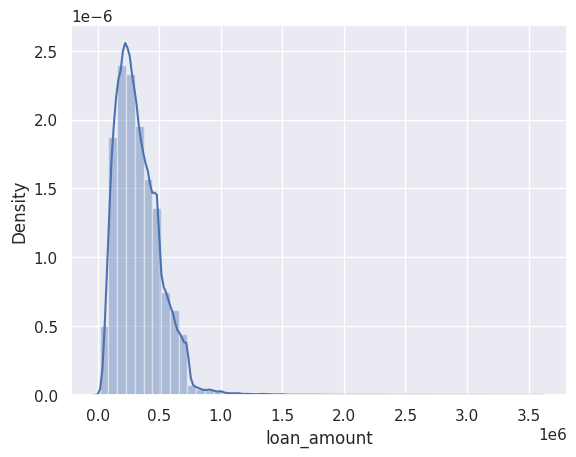

In [ ]:
sns.distplot(df['loan_amount'])

<Axes: xlabel='Status', ylabel='loan_amount'>

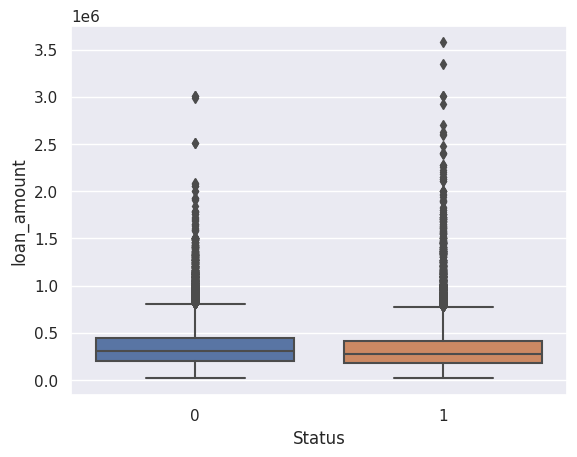

In [ ]:
sns.boxplot(data=df , x='Status' , y ='loan_amount')

<Axes: xlabel='Status', ylabel='term'>

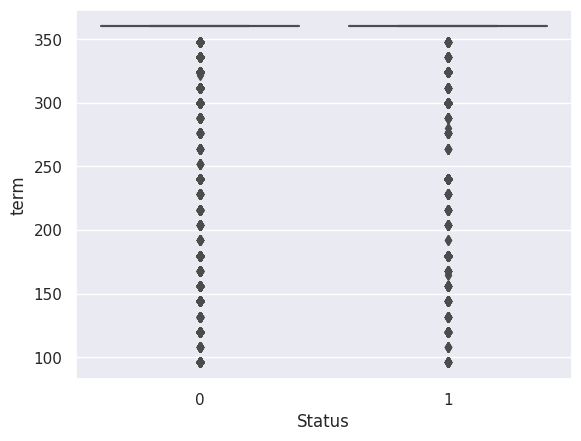

In [ ]:
sns.boxplot(data=df , x='Status' , y ='term')

<Axes: xlabel='Status', ylabel='income'>

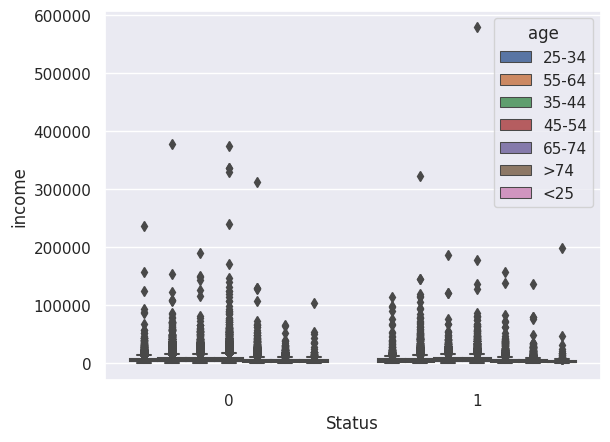

In [ ]:
sns.boxplot(data=df , x='Status' , y ='income' , hue='age')

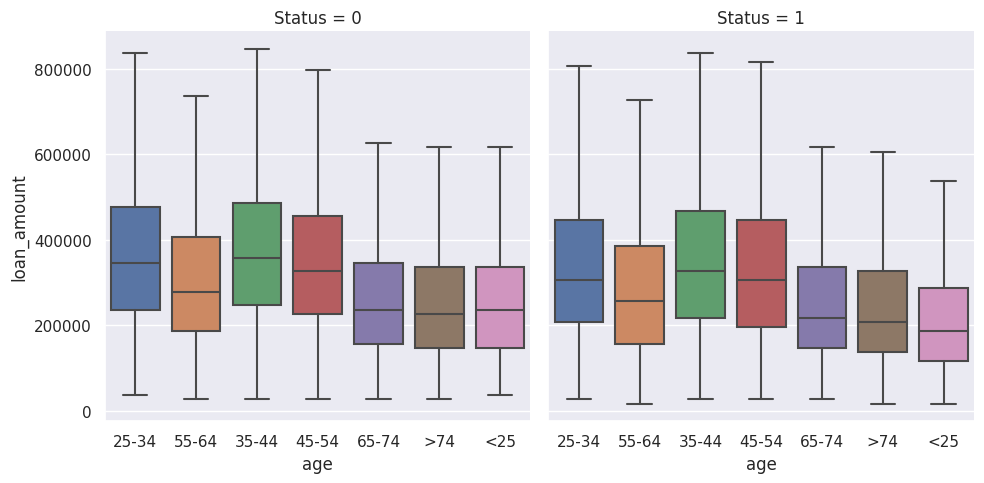

In [ ]:
sns.catplot(data=df,x='age',y='loan_amount',kind='box',col='Status',sym="")

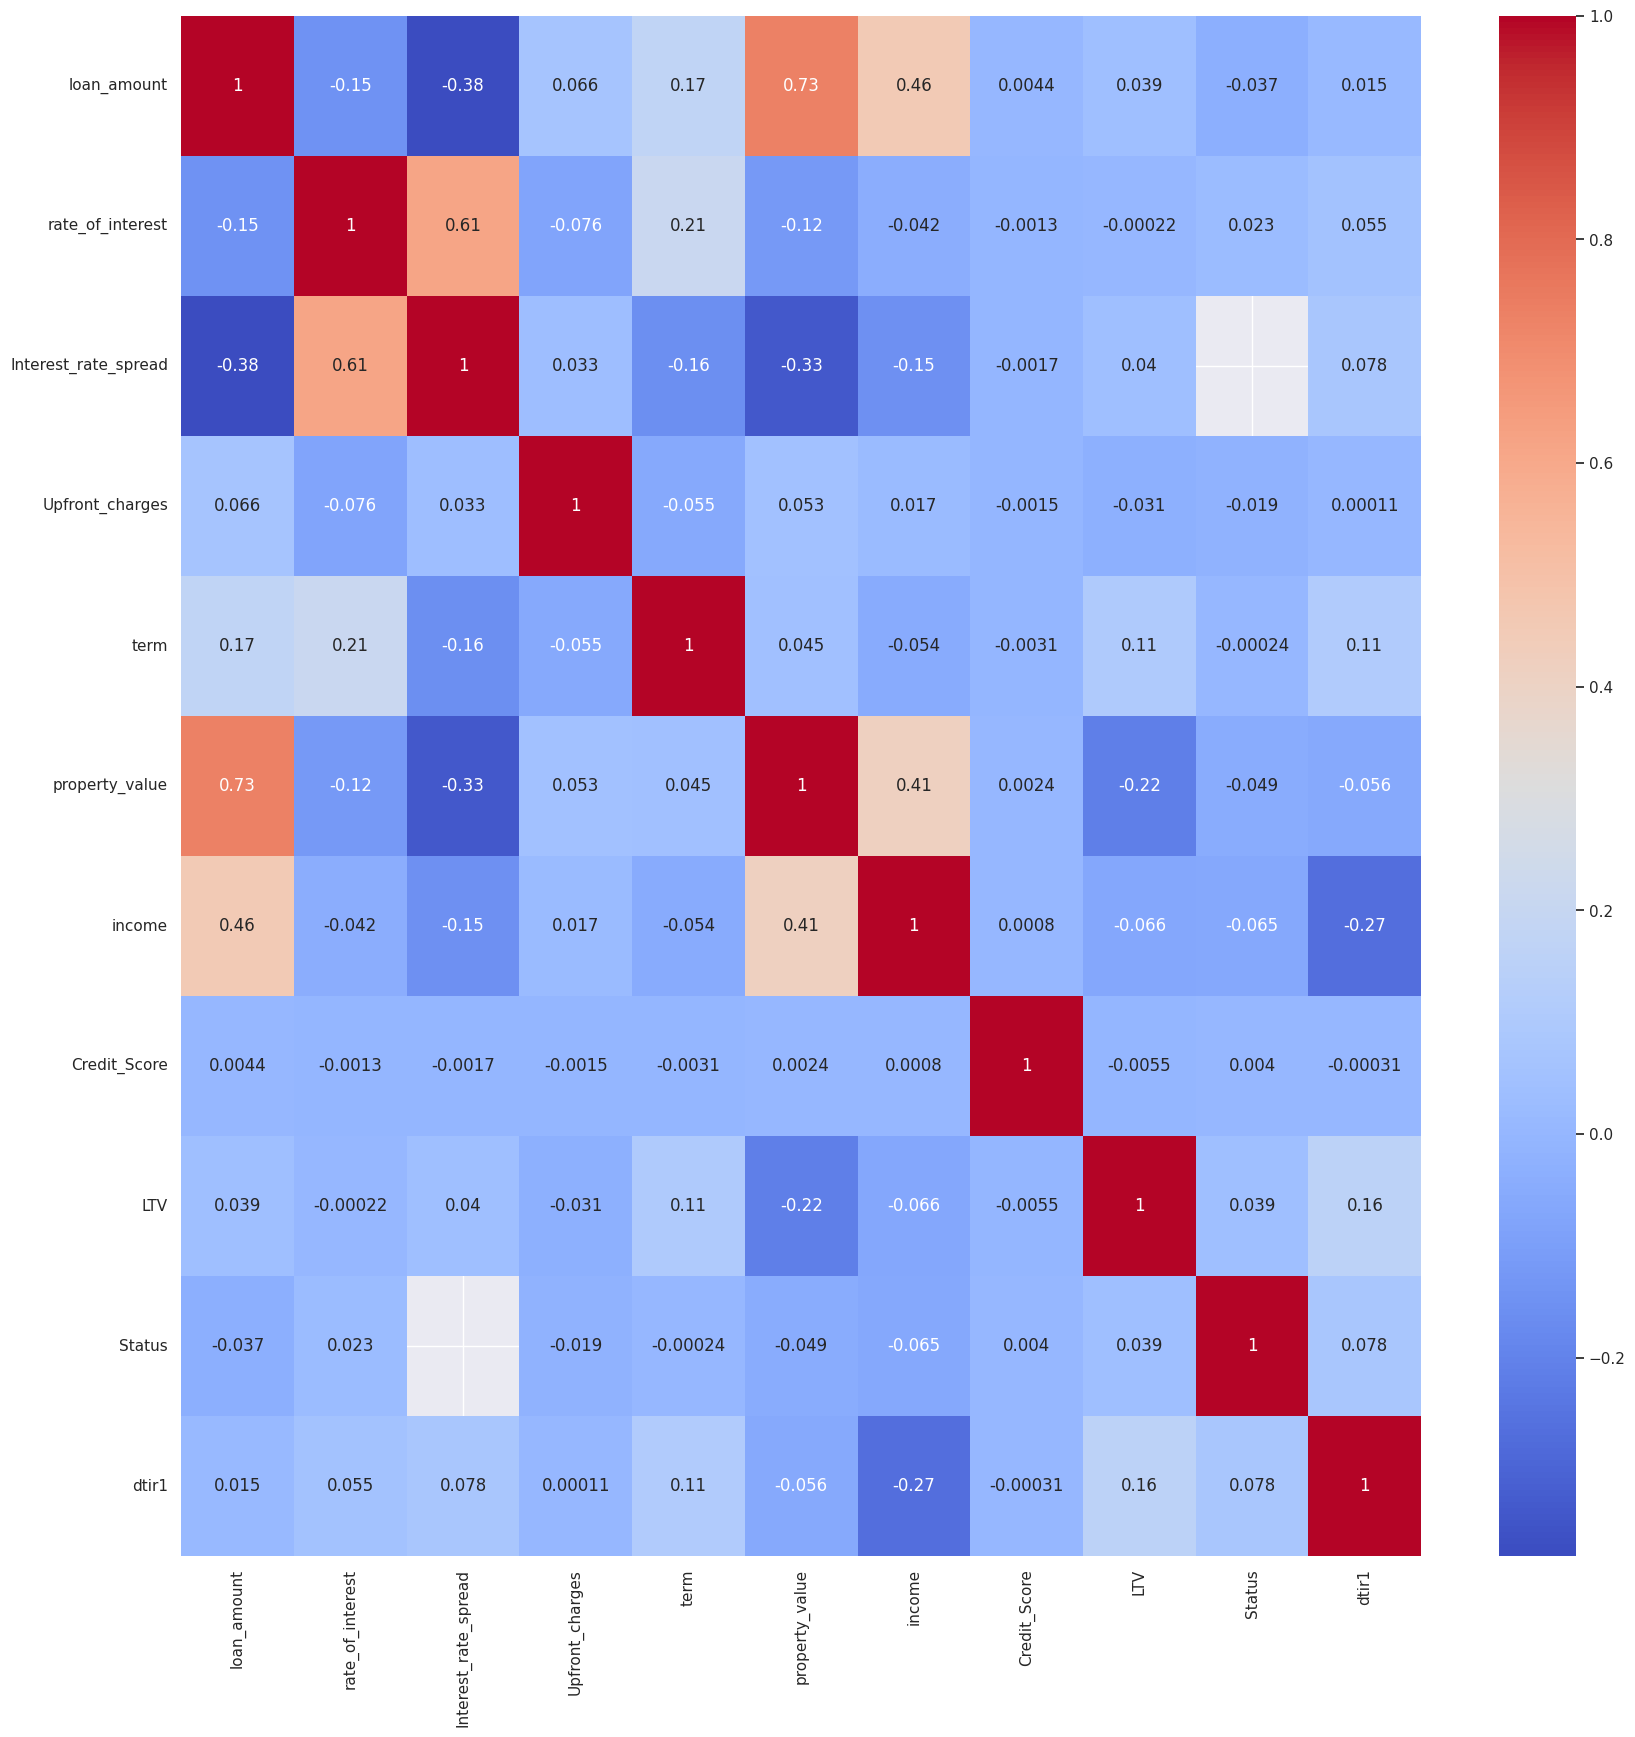

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


# Now we will handle Missing value

In [ ]:
cat_vars = []
num_vars = []
for i in df.columns:
    if(df[i].dtype == "object"):
        cat_vars.append(i)
    else:
        num_vars.append(i)
print("Categorical Variables:\n",cat_vars,"\n")
print("Numerical Variables:\n",num_vars,"\n")

Categorical Variables:
 ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type'] 

Numerical Variables:
 ['loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'Status', 'dtir1'] 



## Imputing Numericals vars:

In [ ]:
df_num = df[num_vars]
knn = KNNImputer(n_neighbors = 3)
knn.fit(df_num)
X = knn.fit_transform(df_num)


In [ ]:
X

array([[ 1.16500000e+05,  3.58333333e+00, -3.12666667e-02, ...,
         9.87288136e+01,  1.00000000e+00,  4.50000000e+01],
       [ 2.06500000e+05,  3.70833333e+00,  5.22966667e-01, ...,
         8.47955494e+01,  1.00000000e+00,  3.46666667e+01],
       [ 4.06500000e+05,  4.56000000e+00,  2.00000000e-01, ...,
         8.00196850e+01,  0.00000000e+00,  4.60000000e+01],
       ...,
       [ 4.46500000e+05,  3.12500000e+00,  8.16000000e-02, ...,
         6.13324176e+01,  0.00000000e+00,  4.90000000e+01],
       [ 1.96500000e+05,  3.50000000e+00,  5.82400000e-01, ...,
         7.06834532e+01,  0.00000000e+00,  2.90000000e+01],
       [ 4.06500000e+05,  4.37500000e+00,  1.38710000e+00, ...,
         7.28494624e+01,  0.00000000e+00,  4.40000000e+01]])

In [ ]:
df_num = pd.DataFrame(X, columns=num_vars)
df_num.isna().sum()

loan_amount             0
rate_of_interest        0
Interest_rate_spread    0
Upfront_charges         0
term                    0
property_value          0
income                  0
Credit_Score            0
LTV                     0
Status                  0
dtir1                   0
dtype: int64

## Imputing Categorical vars:

In [ ]:
df_cat = df[cat_vars]
for i in cat_vars:
    mode = df[i].mode()
    mode = mode[0]
    df_cat[i].fillna(value=mode, inplace=True)

df_cat.isna().sum()

loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
credit_type                  0
co-applicant_credit_type     0
age                          0
submission_of_application    0
Region                       0
Security_Type                0
dtype: int64

Joining both dataframes:

In [ ]:
df_full = pd.concat([df_num, df_cat], axis=1, join='inner')
df_full.isna().sum()

loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
property_value               0
income                       0
Credit_Score                 0
LTV                          0
Status                       0
dtir1                        0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
credit_type                  0
co-applicant_credit_type     0
age                          0
submission_of_application    0
Region                       0
Security_Type                0
dtype: i

# Outlier Detection and Removal:

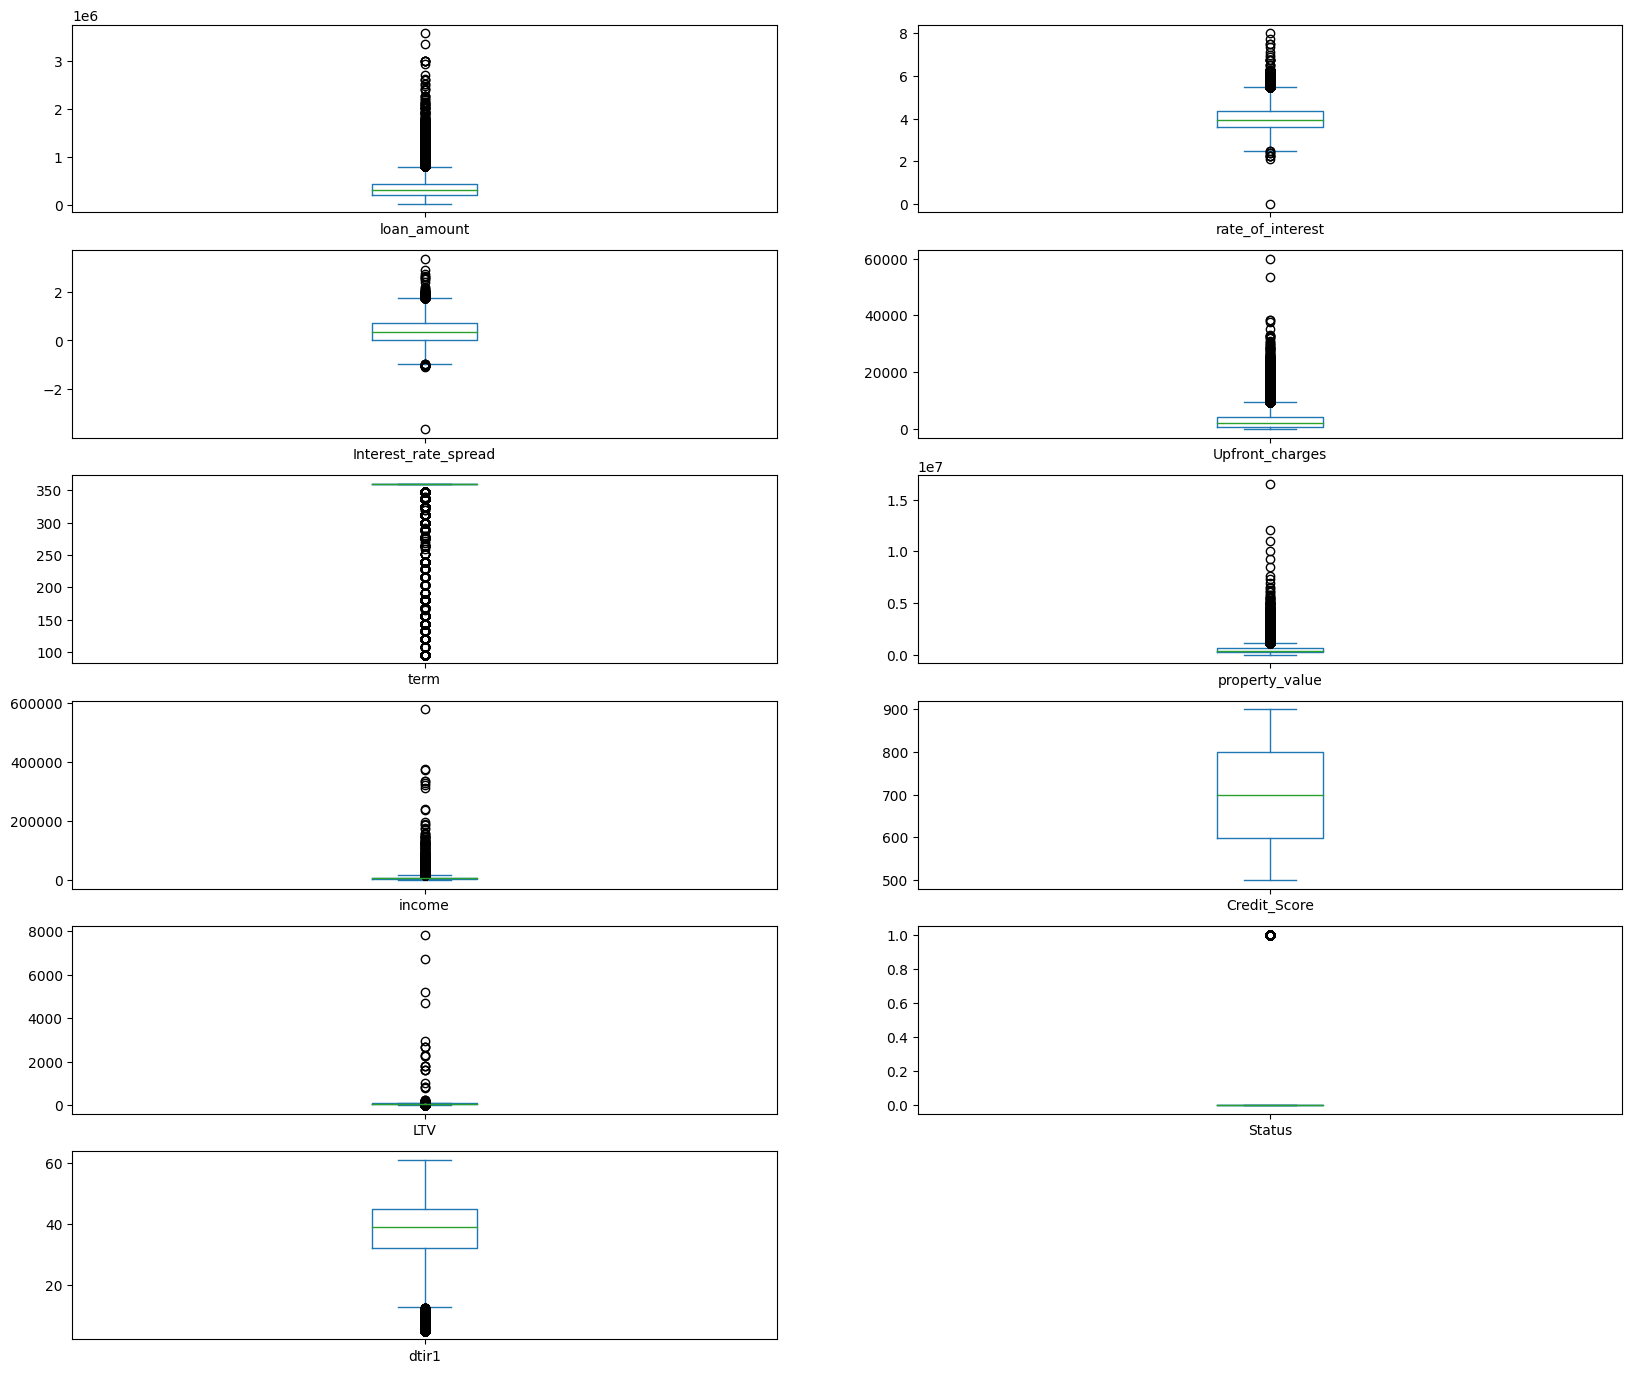

In [ ]:
df_full.plot(kind="box",subplots=True,layout=(7,2),figsize=(20,20));

Inference: Almost all numerical variables have outliers present except for Credit_Score.

Plots after removing outliers:



loan_amount                Axes(0.125,0.786098;0.352273x0.0939024)
rate_of_interest        Axes(0.547727,0.786098;0.352273x0.0939024)
Interest_rate_spread       Axes(0.125,0.673415;0.352273x0.0939024)
Upfront_charges         Axes(0.547727,0.673415;0.352273x0.0939024)
term                       Axes(0.125,0.560732;0.352273x0.0939024)
property_value          Axes(0.547727,0.560732;0.352273x0.0939024)
income                     Axes(0.125,0.448049;0.352273x0.0939024)
Credit_Score            Axes(0.547727,0.448049;0.352273x0.0939024)
LTV                        Axes(0.125,0.335366;0.352273x0.0939024)
Status                  Axes(0.547727,0.335366;0.352273x0.0939024)
dtir1                      Axes(0.125,0.222683;0.352273x0.0939024)
dtype: object

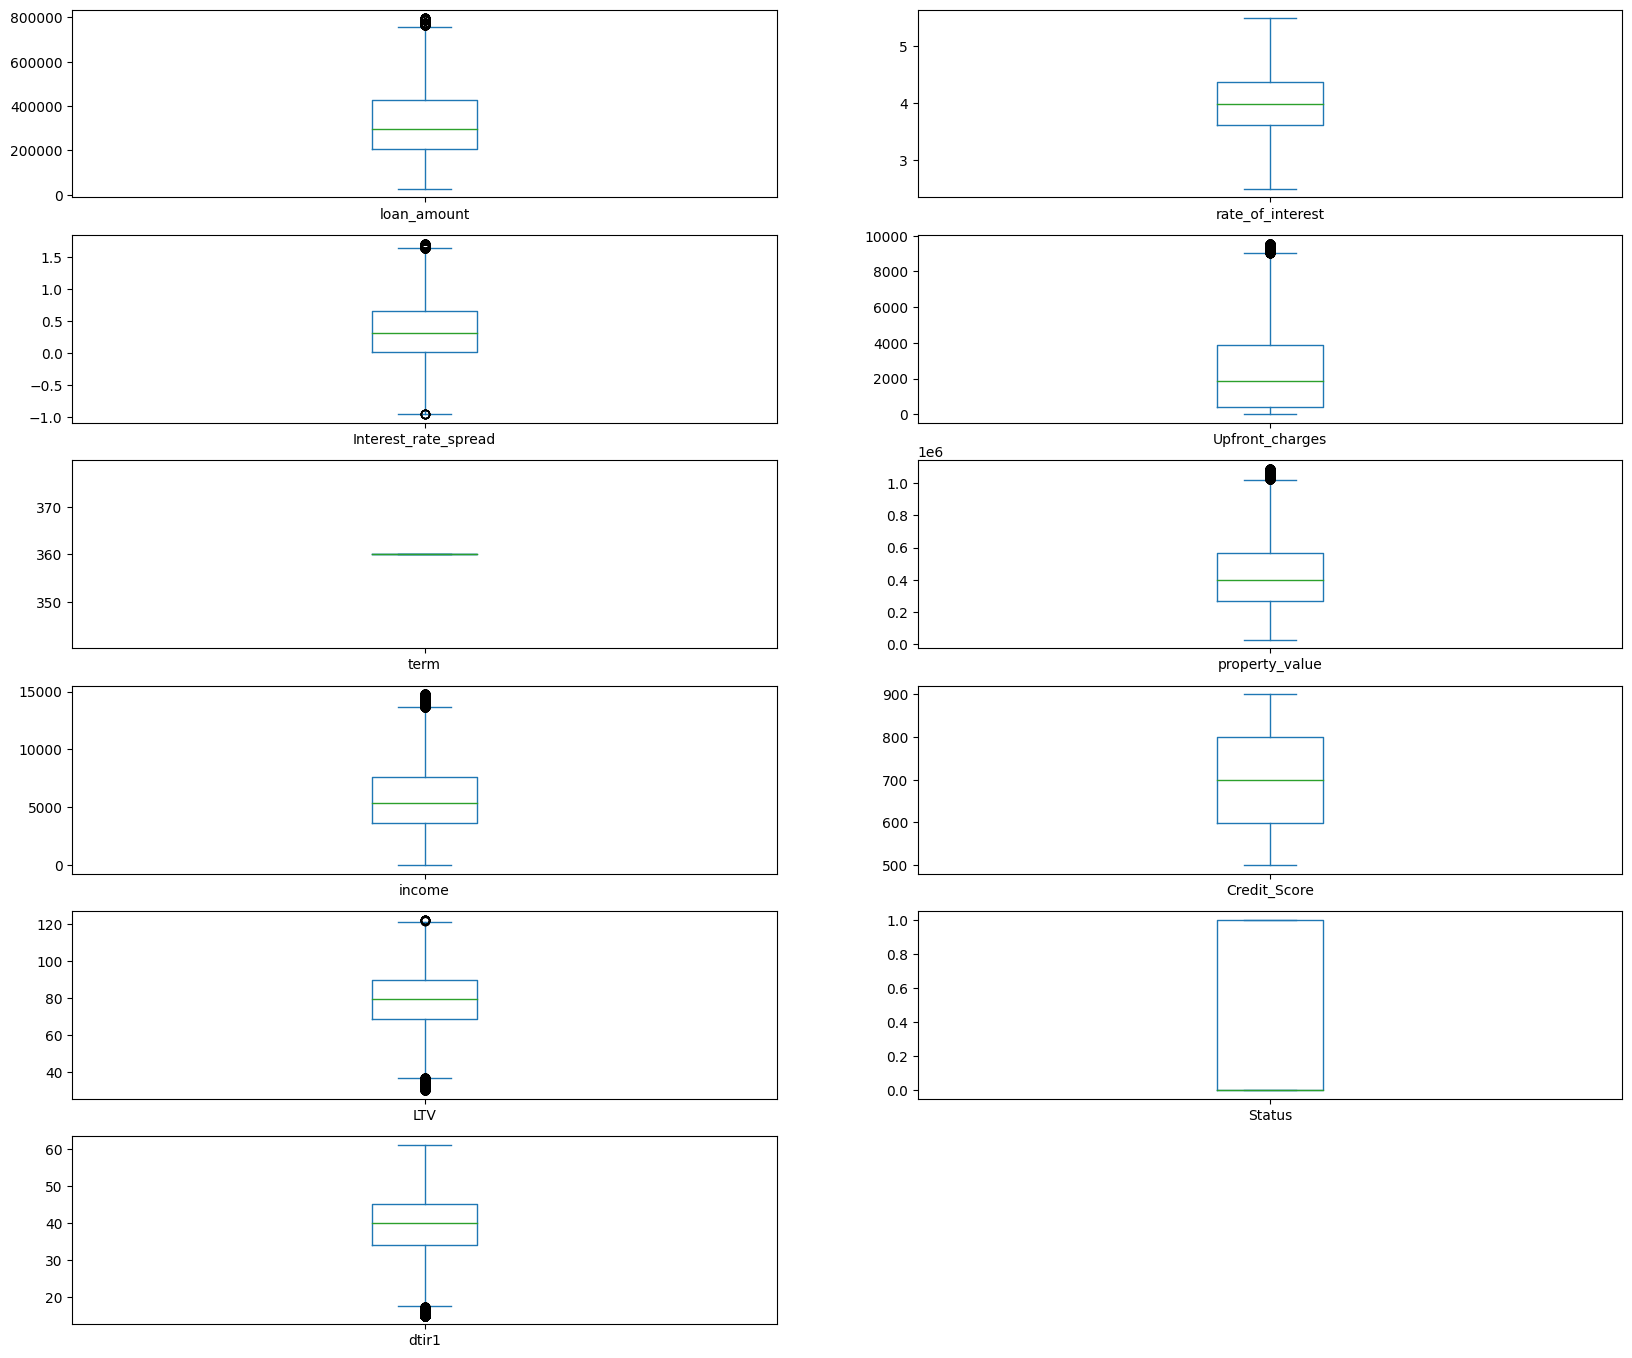

In [ ]:
def drop_outliers(df, field_name):
    iqr = 1.5 * (np.percentile(df[field_name], 75) - np.percentile(df[field_name], 25))
    upper_bound = iqr + np.percentile(df[field_name], 75)
    lower_bound = np.percentile(df[field_name], 25) - iqr

    if ((df[field_name] > upper_bound) | (df[field_name] < lower_bound)).empty:
        print("No outliers to drop.")
        return

    df.drop(df[(df[field_name] > upper_bound) | (df[field_name] < lower_bound)].index, inplace=True)

drop_outliers(df_full, "loan_amount")
drop_outliers(df_full, "rate_of_interest")
drop_outliers(df_full, "Interest_rate_spread")
drop_outliers(df_full, "Upfront_charges")
drop_outliers(df_full, "property_value")
drop_outliers(df_full, "income")
drop_outliers(df_full, "LTV")
drop_outliers(df_full, "Status")
drop_outliers(df_full, "term")
drop_outliers(df_full, "dtir1")

print("Plots after removing outliers:\n")
df_full.plot(kind="box", subplots=True, layout=(7,2), figsize=(20,20))


Inference: Outliers have been removed.

In [ ]:
df_full.shape

(102473, 32)

<Axes: >

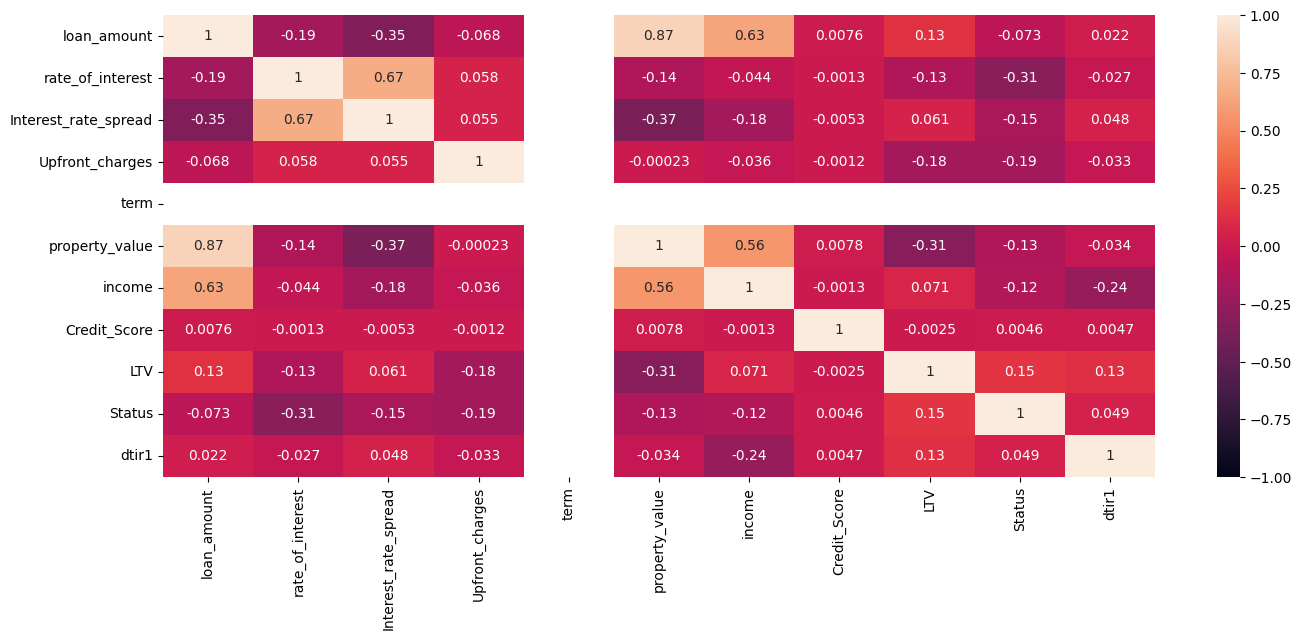

In [ ]:
corr = df_full[num_vars].corr()
plt.figure(figsize=(16, 6))
sns.heatmap(data = corr, vmin=-1, vmax=1, annot=True)

Inference: High positive Correlation can be seen between property_value and loan_amount .

# Encoding Categorical Variables:

In [ ]:
print(df_full[cat_vars].nunique().sum)

<bound method Series.sum of loan_limit                   2
Gender                       4
approv_in_adv                2
loan_type                    3
loan_purpose                 4
Credit_Worthiness            2
open_credit                  2
business_or_commercial       2
Neg_ammortization            2
interest_only                2
lump_sum_payment             2
construction_type            2
occupancy_type               3
Secured_by                   2
total_units                  4
credit_type                  4
co-applicant_credit_type     2
age                          7
submission_of_application    2
Region                       4
Security_Type                2
dtype: int64>


In [ ]:
label = LabelEncoder()
for i in cat_vars:
    df_full[i] = label.fit_transform(df_full[i])

In [ ]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102473 entries, 0 to 148666
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_amount                102473 non-null  float64
 1   rate_of_interest           102473 non-null  float64
 2   Interest_rate_spread       102473 non-null  float64
 3   Upfront_charges            102473 non-null  float64
 4   term                       102473 non-null  float64
 5   property_value             102473 non-null  float64
 6   income                     102473 non-null  float64
 7   Credit_Score               102473 non-null  float64
 8   LTV                        102473 non-null  float64
 9   Status                     102473 non-null  float64
 10  dtir1                      102473 non-null  float64
 11  loan_limit                 102473 non-null  int64  
 12  Gender                     102473 non-null  int64  
 13  approv_in_adv              102473 

Data is cleaned now

# Train test split

In [ ]:
train_set, test_set = train_test_split(df_full, test_size=0.2, random_state=42)

y_train = train_set['Status']
X_train = train_set.drop(columns=['Status'])
y_test = test_set['Status']
X_test = test_set.drop(columns=['Status'])

In [ ]:
print("Shape of x_train: ", X_train.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of x_test: ", X_test.shape)
print("Shape of y_test: ", y_test.shape)

Shape of x_train:  (81978, 31)
Shape of y_train:  (81978,)
Shape of x_test:  (20495, 31)
Shape of y_test:  (20495,)


# Initialzing Boosting Models:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
log_reg = LogisticRegression(random_state = 42)
gdb = GradientBoostingClassifier(random_state = 42)
adab = AdaBoostClassifier(random_state = 42)
lgb = LGBMClassifier(random_state = 42)
catb = CatBoostClassifier(random_state = 42)
xgb = XGBClassifier(random_state = 42)

In [ ]:
# Logistic Regression Model

log_reg.fit(X_train, y_train)

# Predictions and evaluation
y_pred = log_reg.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


[[15329    10]
 [ 5120    36]]
              precision    recall  f1-score   support

         0.0       0.75      1.00      0.86     15339
         1.0       0.78      0.01      0.01      5156

    accuracy                           0.75     20495
   macro avg       0.77      0.50      0.44     20495
weighted avg       0.76      0.75      0.64     20495

Accuracy: 0.7496950475725787


In [ ]:
# Random Forest Model

rf_clf.fit(X_train, y_train)

# Predictions and evaluation
y_pred_rf = rf_clf.predict(X_test)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


[[15147   192]
 [  961  4195]]
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96     15339
         1.0       0.96      0.81      0.88      5156

    accuracy                           0.94     20495
   macro avg       0.95      0.90      0.92     20495
weighted avg       0.94      0.94      0.94     20495

Accuracy: 0.9437423761893144


In [ ]:
print(rf_clf.score(X_train,y_train))

1.0


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

# Evaluate the best model
best_rf_clf = grid_search.best_estimator_
train_accuracy = best_rf_clf.score(X_train, y_train)
test_accuracy = best_rf_clf.score(X_test, y_test)

print(f"Best Model Training Accuracy: {train_accuracy}")
print(f"Best Model Test Accuracy: {test_accuracy}")

# Check if overfitting is reduced
if train_accuracy > 0.95 and test_accuracy < train_accuracy - 0.1:
    print("The model is still likely overfitting.")
else:
    print("The model is not overfitting.")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  18.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  39.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  58.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  19.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  19.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  38.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  38.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=  58.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  19.1s
[CV] END 

# Gradient Boosting:

In [ ]:
gdb.fit(X_train, y_train)
y_pred_gdb = gdb.predict(X_test)
print('Accuracy :',accuracy_score(y_test, y_pred_gdb))
print("\n")
print(classification_report(y_test, y_pred_gdb))

Accuracy : 0.9369114418150768


              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96     15339
         1.0       0.97      0.77      0.86      5156

    accuracy                           0.94     20495
   macro avg       0.95      0.88      0.91     20495
weighted avg       0.94      0.94      0.93     20495



# XGBoost:

In [ ]:
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print('Accuracy :',accuracy_score(y_test, y_pred_xgb))
print("\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy : 0.9747743352037083


              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     15339
         1.0       0.98      0.92      0.95      5156

    accuracy                           0.97     20495
   macro avg       0.98      0.96      0.97     20495
weighted avg       0.97      0.97      0.97     20495



Using SelectFromModel approach on XGBoost to select features with specified threshold of importance.

In [ ]:
from sklearn.feature_selection import SelectFromModel
sfm = SelectFromModel(xgb)

xgb2 = sfm.fit(X_train, y_train)
selected_features = X_train.columns[sfm.get_support()]
print(selected_features)

Index(['rate_of_interest', 'loan_type', 'Neg_ammortization',
       'lump_sum_payment', 'credit_type', 'submission_of_application'],
      dtype='object')


# LightGBM:

In [ ]:
lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)
print('Accuracy :',accuracy_score(y_test, y_pred_lgb))
print("\n")
print(classification_report(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 20577, number of negative: 61401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1901
[LightGBM] [Info] Number of data points in the train set: 81978, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.251006 -> initscore=-1.093252
[LightGBM] [Info] Start training from score -1.093252
Accuracy : 0.9813125152476214


              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     15339
         1.0       0.99      0.94      0.96      5156

    accuracy                           0.98     20495
   macro avg       0.98      0.97      0.97     20495
weighted avg       0.98      0.98      0.98     20495



# CatBoost:

In [ ]:
catb.fit(X_train, y_train)
y_pred_catb = catb.predict(X_test)
print('Accuracy :',accuracy_score(y_test, y_pred_catb))
print("\n")
print(classification_report(y_test, y_pred_catb))

Learning rate set to 0.067621
0:	learn: 0.6194468	total: 68.8ms	remaining: 1m 8s
1:	learn: 0.5619323	total: 83.4ms	remaining: 41.6s
2:	learn: 0.5273232	total: 97.2ms	remaining: 32.3s
3:	learn: 0.4999902	total: 110ms	remaining: 27.4s
4:	learn: 0.4751753	total: 126ms	remaining: 25s
5:	learn: 0.4530342	total: 142ms	remaining: 23.5s
6:	learn: 0.4239151	total: 156ms	remaining: 22.1s
7:	learn: 0.3981619	total: 171ms	remaining: 21.2s
8:	learn: 0.3834097	total: 184ms	remaining: 20.3s
9:	learn: 0.3718269	total: 199ms	remaining: 19.7s
10:	learn: 0.3558495	total: 213ms	remaining: 19.1s
11:	learn: 0.3457303	total: 228ms	remaining: 18.8s
12:	learn: 0.3354237	total: 242ms	remaining: 18.3s
13:	learn: 0.3277177	total: 255ms	remaining: 18s
14:	learn: 0.3201628	total: 268ms	remaining: 17.6s
15:	learn: 0.3085839	total: 284ms	remaining: 17.4s
16:	learn: 0.3016052	total: 297ms	remaining: 17.2s
17:	learn: 0.2965985	total: 310ms	remaining: 16.9s
18:	learn: 0.2907999	total: 324ms	remaining: 16.7s
19:	learn: 0

# AdaBoost:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
base_classifier = DecisionTreeClassifier(max_depth=1)
adab = AdaBoostClassifier(base_estimator=base_classifier, random_state=42)
adab.fit(X_train, y_train)
y_pred_adab = adab.predict(X_test)
print('Accuracy :',accuracy_score(y_test, y_pred_adab))
print("\n")
print(classification_report(y_test, y_pred_adab))

Accuracy : 0.9050500121980971


              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94     15339
         1.0       0.90      0.70      0.79      5156

    accuracy                           0.91     20495
   macro avg       0.90      0.84      0.86     20495
weighted avg       0.90      0.91      0.90     20495



# Scores Compilation:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

trained_models = [log_reg, rf_clf, adab, gdb, xgb, lgb, catb]
model_names = ["LogisticRegression", "RandomForestClassifier", "AdaBoost", "GradientBoost", "XGBoost", "LGBoost", "CatBoost"]
model_list = list(zip(model_names, trained_models))

train_accuracy_scores = []
test_accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for model_name, model in model_list:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_accuracy_scores.append(accuracy_score(y_train, y_train_pred))
    test_accuracy_scores.append(accuracy_score(y_test, y_test_pred))
    precision_scores.append(precision_score(y_test, y_test_pred))
    recall_scores.append(recall_score(y_test, y_test_pred))
    f1_scores.append(f1_score(y_test, y_test_pred))

metrics_df = pd.DataFrame({
    'Model': model_names,
    'Train Accuracy': train_accuracy_scores,
    'Test Accuracy': test_accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

metrics_df



,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0.750909,0.749695,0.782609,0.006982,0.013841
1,RandomForestClassifier,1.000000,0.943742,0.956234,0.813615,0.879178
2,AdaBoost,0.904596,0.905050,0.902659,0.697828,0.787136
3,GradientBoost,0.936910,0.936911,0.973988,0.769783,0.859929
4,XGBoost,0.984630,0.974774,0.977952,0.920481,0.948346
5,LGBoost,0.982886,0.981313,0.988937,0.936191,0.961841
6,CatBoost,0.989790,0.984826,0.990087,0.949185,0.969205


**Inference:** All the evaluation metrics values are increasing with each successive boosting model with best results given by CatBoost. Catboost is already giving accuracy of 98% so there is no need for stacking or hyperparametertuning.